# Detecting a conical intersection with a variational Berry phase at CASSCF level

**The question.** Given a closed loop in nuclear coordinate space, *does it enclose a conical
intersection?*

Two independent workflows answer it for formaldimine (H<sub>2</sub>C=NH) in STO-3G:

1. **Berry phase.** Track the state-specific CASSCF ground state S0 around the loop by
   continuation, and read the Z2 Berry phase off the *sign* of the initial-final overlap.
   A non-trivial phase (&pi;) means the loop encloses a CI.
2. **State-averaged comparator.** Resolve S0 and S1 with equal-weight SA-CASSCF on a grid
   covering the enclosed region and look for the gap closing.

The loops follow arXiv:2304.06070 and the `auto_oo` Berry-phase tutorial: three circles of
radius 10&deg; in the (&alpha;, &phi;) plane centred at &phi; = 89.9&deg; and
&alpha; = 110&deg; (`C_1`), 130&deg; (`C_x`), 150&deg; (`C_2`). Only `C_x` encloses the CI.
Full provenance is in `docs/provenance.md`.

**Headline results.**

| | Berry phase | SA-CASSCF comparator |
|---|---|---|
| `C_x` (encloses CI) | **&pi;** at CAS(2,2), (4,4), (6,6) | CI found inside, from CAS(4,4) up |
| `C_1`, `C_2` (controls) | **0** at CAS(2,2), (4,4), (6,6) | no CI inside, from CAS(4,4) up |

All 36 Berry-phase runs agree across four discretizations. The comparator, however,
**fails qualitatively at CAS(2,2)**: it invents a conical intersection inside the trivial
loop `C_2` and misses the real one. That asymmetry is the main scientific finding here and is
dissected in the last section.

In [1]:
import glob, json, os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

sys.path.insert(0, os.path.abspath(".."))
from berrycasscf.geometry import BENCHMARK_LOOPS, REFERENCE_CI_ALPHA_PHI
from berrycasscf.report import load_berry_records, berry_table, format_table, stability_verdict
from berrycasscf.scan import ScanResult

ROOT = os.path.abspath("..")
BERRY_DIR = os.path.join(ROOT, "results", "berry")
SCAN_DIR = os.path.join(ROOT, "results", "scan")

records = load_berry_records(BERRY_DIR)
rows = berry_table(records)
print(f"{len(rows)} Berry-phase runs, {len(glob.glob(os.path.join(SCAN_DIR,'*.npz')))} scans loaded")

LOOP_COLOUR = {"C_1": "tab:blue", "C_x": "tab:red", "C_2": "tab:green"}
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.facecolor": "white"})

def load_scan(name, cas, grid="25x25"):
    path = os.path.join(SCAN_DIR, f"{name}_cas{cas}_{grid}.npz")
    return ScanResult.load(path) if os.path.exists(path) else None

import matplotlib.patheffects as pe
OUTLINE = [pe.withStroke(linewidth=2.5, foreground="white")]

def draw_loops(ax, names=("C_1", "C_x", "C_2"), lw=1.8, dx=0.0, dy=0.0):
    for n in names:
        lp = BENCHMARK_LOOPS[n]
        ax.add_patch(Ellipse((lp.centre[1], lp.centre[0]), 2*lp.radius[1], 2*lp.radius[0],
                             fill=False, lw=lw, ec=LOOP_COLOUR[n], zorder=5))
        ax.text(lp.centre[1]+dx, lp.centre[0]+dy, n, color=LOOP_COLOUR[n], ha="center",
                va="center", fontweight="bold", zorder=6, fontsize=10,
                path_effects=OUTLINE)

36 Berry-phase runs, 11 scans loaded


## 1. The loops, and where the conical intersection actually is

The background is the equal-weight SA-CASSCF(4,4) S1&minus;S0 gap over a region spanning all
three loops. The gap collapses to a point inside `C_x`; the controls sit on smooth slopes.
The cross marks the literature CI position (&alpha; &asymp; 132&deg;, &phi; = 90&deg;) from
the FCI map of arXiv:2304.06070.

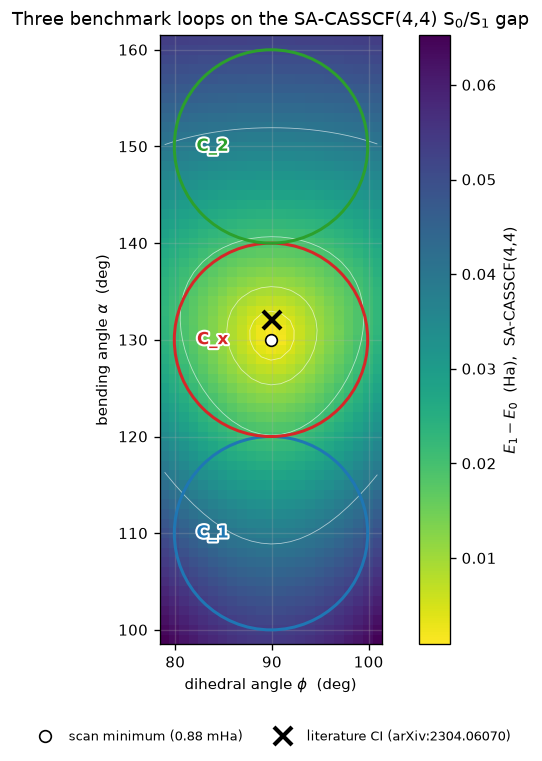

In [2]:
ov = load_scan("overview", "4-4", "63x23")
fig, ax = plt.subplots(figsize=(6.6, 6.4))
if ov is not None:
    A, P = np.meshgrid(ov.alphas, ov.phis, indexing="ij")
    pcm = ax.pcolormesh(P, A, ov.gap, shading="nearest", cmap="viridis_r")
    fig.colorbar(pcm, ax=ax, label=r"$E_1 - E_0$  (Ha),  SA-CASSCF(4,4)")
    ax.contour(P, A, ov.gap, levels=[0.005, 0.01, 0.02, 0.04], colors="w", linewidths=0.5, alpha=0.6)
    a_min, p_min, g_min = ov.min_gap_point()
    ax.plot(p_min, a_min, "wo", ms=7, mec="k", zorder=7, label=f"scan minimum ({g_min*1e3:.2f} mHa)")
draw_loops(ax, dx=-6.0)
ax.plot(REFERENCE_CI_ALPHA_PHI[1], REFERENCE_CI_ALPHA_PHI[0], "kx", ms=11, mew=2.5,
        zorder=7, label="literature CI (arXiv:2304.06070)")
ax.set_xlabel(r"dihedral angle $\phi$  (deg)"); ax.set_ylabel(r"bending angle $\alpha$  (deg)")
ax.set_title("Three benchmark loops on the SA-CASSCF(4,4) S$_0$/S$_1$ gap")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8, frameon=False)
ax.set_aspect("equal"); plt.tight_layout(); plt.show()

## 2. Validation first: a model with a known answer

Before any quantum chemistry, the sign convention and both estimators are checked on the 2&times;2
linear Jahn-Teller (E&otimes;e) model, whose Berry phase is &pi; for loops enclosing the
intersection and 0 otherwise. Each freshly diagonalized eigenvector is multiplied by a random
&plusmn;1, imitating the arbitrary sign a CASSCF solver returns: a correct implementation must
be completely insensitive to it.

In [3]:
from berrycasscf.toy import jt_loop_berry_phase
cases = [((0,0), 1.0, 24), ((0,0), 1.0, 7), ((0,0), 3.0, 40),
         ((2.0,0), 1.0, 24), ((0,5.0), 2.0, 24),
         ((0.99,0), 1.0, 64), ((1.01,0), 1.0, 64)]
print(f"{'loop':28s} {'product':>10s} {'endpoint':>10s} {'min|ovl|':>9s}  {'encloses':>8s}  verdict")
print("-"*80)
for c, r, n in cases:
    res = jt_loop_berry_phase(centre=c, radius=r, n_points=n)
    print(f"centre={str(c):10s} r={r:<4g} N={n:<3d} {res.product_estimator:+10.5f} "
          f"{res.endpoint_estimator:+10.5f} {res.min_abs_adjacent_overlap:9.4f}  "
          f"{str(res.encloses_origin):>8s}  {'OK' if res.agrees_with_theory else 'FAIL'}")

signs = {np.sign(jt_loop_berry_phase(centre=(0,0), radius=1.0, n_points=11, seed=s).product_estimator)
         for s in range(200)}
print(f"\nGauge invariance over 200 random sign realizations (enclosing loop): {signs}")

loop                            product   endpoint  min|ovl|  encloses  verdict
--------------------------------------------------------------------------------
centre=(0, 0)     r=1    N=24    -0.81366   -1.00000    0.9914      True  OK
centre=(0, 0)     r=1    N=7     -0.48191   -1.00000    0.9010      True  OK
centre=(0, 0)     r=3    N=40    -0.88382   -1.00000    0.9969      True  OK
centre=(2.0, 0)   r=1    N=24    +0.96668   +1.00000    0.9925     False  OK
centre=(0, 5.0)   r=2    N=24    +0.98077   +1.00000    0.9965     False  OK
centre=(0.99, 0)  r=1    N=64    -0.51499   -1.00000    0.7255      True  OK
centre=(1.01, 0)  r=1    N=64    +0.56507   +1.00000    0.7581     False  OK

Gauge invariance over 200 random sign realizations (enclosing loop): {np.float64(-1.0)}


The last two rows are the delicate ones: circles of radius 1 centred at (0.99, 0) and
(1.01, 0) barely do and barely do not enclose the degeneracy, and the estimators still
separate them cleanly. Note `|product|` drops to ~0.5 there &mdash; **magnitude is a continuity
diagnostic only; all the topological information is in the sign.**

## 3. Energies around the loops

The tracked S0 energy must vary smoothly. A jump would mean the continuation lost the
solution.

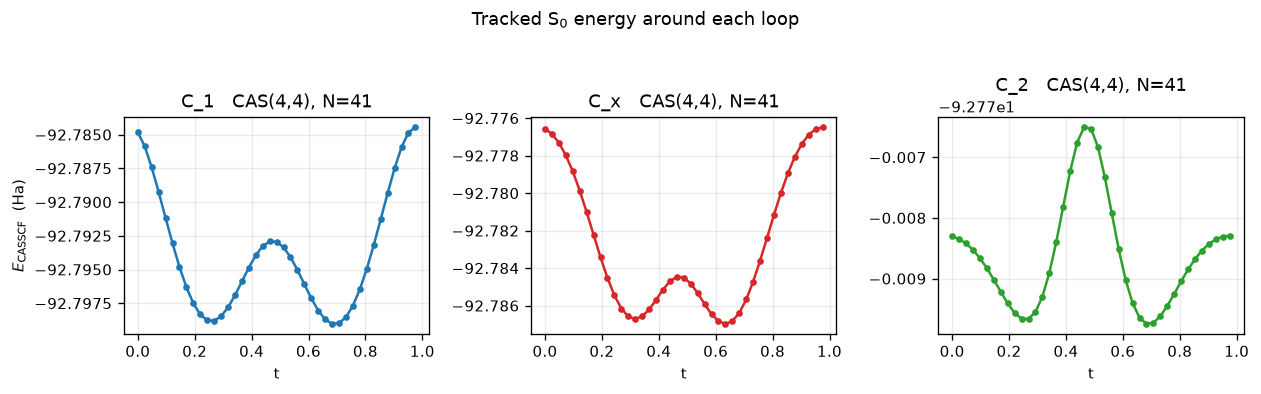

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.1), sharex=True)
for ax, name in zip(axes, ["C_1", "C_x", "C_2"]):
    for rec in records:
        if rec["loop_name"] == name and rec["cas_label"] == "CAS(4,4)" and rec["n_points"] == 41:
            pts = rec["_traversal"]["points"]
            t = [p["t"] for p in pts]; e = [p["energy"] for p in pts]
            ax.plot(t, e, "o-", ms=3, color=LOOP_COLOUR[name])
    ax.set_title(f"{name}   CAS(4,4), N=41"); ax.set_xlabel("t")
axes[0].set_ylabel(r"$E_{\rm CASSCF}$  (Ha)")
fig.suptitle("Tracked S$_0$ energy around each loop", y=1.04); plt.tight_layout(); plt.show()

## 4. Overlap diagnostics: where the Berry phase actually comes from

For each step the **raw** overlap `<Psi_{k-1}|Psi_k>` is recorded *before* gauge fixing. Its
sign is arbitrary &mdash; CASSCF returns an arbitrary overall sign at each point &mdash; which is
exactly why the sign must be fixed sequentially rather than trusted.

The left panel shows the raw signed overlaps (note how many are negative: the gauge fixing is
doing real work). The right panel shows the running product of the *gauge-fixed* overlaps,
which ends on the closing overlap and whose final sign is the Berry phase.

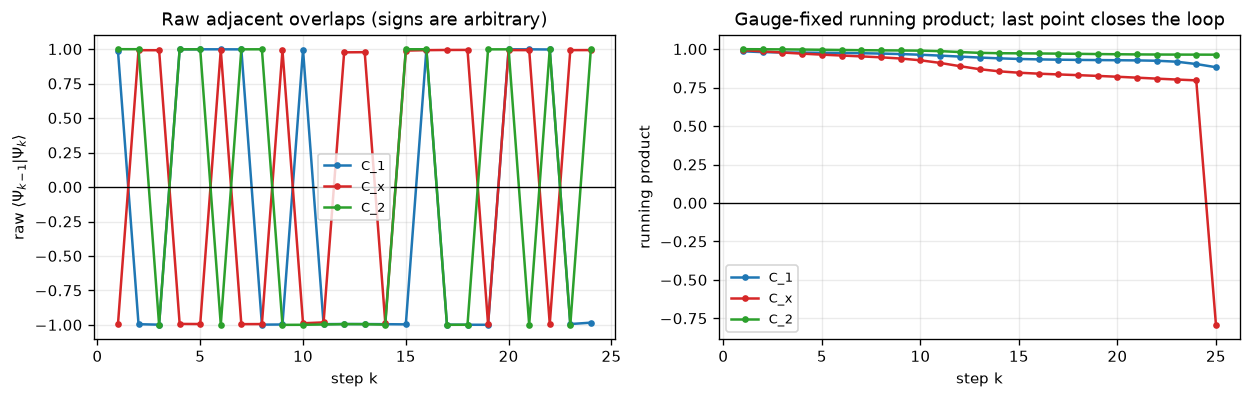

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
for name in ["C_1", "C_x", "C_2"]:
    for rec in records:
        if rec["loop_name"] == name and rec["cas_label"] == "CAS(4,4)" and rec["n_points"] == 25:
            pts = rec["_traversal"]["points"][1:]
            raw = [p["raw_overlap_with_prev"] for p in pts]
            axes[0].plot(range(1, len(raw)+1), raw, "o-", ms=3, color=LOOP_COLOUR[name], label=name)
            run = np.cumprod([abs(v) for v in raw])
            run = np.concatenate([run, [run[-1]*rec["closing_overlap"]]])
            axes[1].plot(range(1, len(run)+1), run, "o-", ms=3, color=LOOP_COLOUR[name], label=name)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_xlabel("step k"); axes[0].set_ylabel(r"raw $\langle\Psi_{k-1}|\Psi_k\rangle$")
axes[0].set_title("Raw adjacent overlaps (signs are arbitrary)"); axes[0].legend(fontsize=8)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("step k"); axes[1].set_ylabel(r"running product")
axes[1].set_title("Gauge-fixed running product; last point closes the loop")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

The final point of the right panel is the **product estimator** &Pi;. For `C_x` it lands
below zero; for both controls above. That sign *is* the Berry phase.

## 5. Berry-phase results and their stability

Two estimators are reported for every run:

* **product** &mdash; the cyclic product of adjacent overlaps, gauge-invariant by construction
  (each wavefunction appears once as bra and once as ket, so arbitrary signs enter squared);
* **endpoint** &mdash; one further continuation step onto the geometry *identical* to the start,
  then `<Psi_0|Psi_N>`. This involves no change of AO basis and so comes out at exactly
  &plusmn;1.

They must agree in sign; a disagreement would be a gauge or continuity bug, not physics, and
is reported as a failure.

In [6]:
print(format_table(rows, ["loop", "CAS", "N", "product", "endpoint", "min|ovl|",
                          "phase", "status"]))

loop  CAS       N   product  endpoint  min|ovl|  phase             status
----  --------  --  -------  --------  --------  ----------------  ------
C_1   CAS(2,2)  9   +0.8067  +1.0000   +0.9653   trivial (0)       OK    
C_1   CAS(2,2)  17  +0.8891  +1.0000   +0.9856   trivial (0)       OK    
C_1   CAS(2,2)  25  +0.9227  +1.0000   +0.9917   trivial (0)       OK    
C_1   CAS(2,2)  41  +0.9519  +1.0000   +0.9964   trivial (0)       OK    
C_1   CAS(4,4)  9   +0.7185  +1.0000   +0.9496   trivial (0)       OK    
C_1   CAS(4,4)  17  +0.8333  +1.0000   +0.9750   trivial (0)       OK    
C_1   CAS(4,4)  25  +0.8825  +1.0000   +0.9835   trivial (0)       OK    
C_1   CAS(4,4)  41  +0.9263  +1.0000   +0.9916   trivial (0)       OK    
C_1   CAS(6,6)  9   +0.7521  +1.0000   +0.9553   trivial (0)       OK    
C_1   CAS(6,6)  17  +0.8552  +1.0000   +0.9795   trivial (0)       OK    
C_1   CAS(6,6)  25  +0.8984  +1.0000   +0.9873   trivial (0)       OK    
C_1   CAS(6,6)  41  +0.9365  +1.0000  

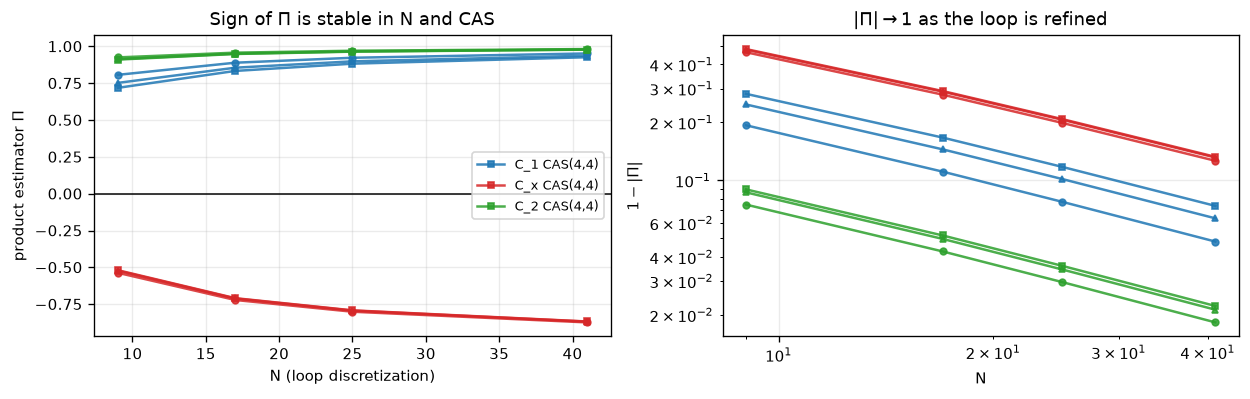

fitted exponent q in  1-|Pi| ~ N^-q :  mean 0.89, range [0.85, 0.93]  over 9 (loop, CAS) series
Stability verdicts (all runs OK, >=2 discretizations, same phase throughout):

  STABLE   C_1  CAS(2,2)  N=[9, 17, 25, 41]  ->  trivial (0)
  STABLE   C_1  CAS(4,4)  N=[9, 17, 25, 41]  ->  trivial (0)
  STABLE   C_1  CAS(6,6)  N=[9, 17, 25, 41]  ->  trivial (0)
  STABLE   C_2  CAS(2,2)  N=[9, 17, 25, 41]  ->  trivial (0)
  STABLE   C_2  CAS(4,4)  N=[9, 17, 25, 41]  ->  trivial (0)
  STABLE   C_2  CAS(6,6)  N=[9, 17, 25, 41]  ->  trivial (0)
  STABLE   C_x  CAS(2,2)  N=[9, 17, 25, 41]  ->  non-trivial (pi)
  STABLE   C_x  CAS(4,4)  N=[9, 17, 25, 41]  ->  non-trivial (pi)
  STABLE   C_x  CAS(6,6)  N=[9, 17, 25, 41]  ->  non-trivial (pi)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
for name in ["C_1", "C_x", "C_2"]:
    for cas, mk in [("CAS(2,2)", "o"), ("CAS(4,4)", "s"), ("CAS(6,6)", "^")]:
        sub = sorted([r for r in rows if r["loop"] == name and r["CAS"] == cas],
                     key=lambda d: d["N"])
        if not sub: continue
        axes[0].plot([r["N"] for r in sub], [r["product"] for r in sub], mk+"-", ms=4,
                     color=LOOP_COLOUR[name], alpha=0.85,
                     label=f"{name} {cas}" if cas == "CAS(4,4)" else None)
        axes[1].plot([r["N"] for r in sub], [1-abs(r["product"]) for r in sub], mk+"-", ms=4,
                     color=LOOP_COLOUR[name], alpha=0.85)
axes[0].axhline(0, color="k", lw=0.9)
axes[0].set_xlabel("N (loop discretization)"); axes[0].set_ylabel(r"product estimator $\Pi$")
axes[0].set_title(r"Sign of $\Pi$ is stable in N and CAS"); axes[0].legend(fontsize=8)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("N"); axes[1].set_ylabel(r"$1-|\Pi|$")
axes[1].set_title(r"$|\Pi| \to 1$ as the loop is refined")
plt.tight_layout(); plt.show()

# Fit the convergence exponent: 1 - |Pi| ~ N^(-q)
slopes = []
for name in ["C_1", "C_x", "C_2"]:
    for cas in ["CAS(2,2)", "CAS(4,4)", "CAS(6,6)"]:
        sub = sorted([r for r in rows if r["loop"] == name and r["CAS"] == cas],
                     key=lambda d: d["N"])
        if len(sub) < 3: continue
        x = np.log([r["N"] for r in sub]); y = np.log([1-abs(r["product"]) for r in sub])
        slopes.append(-np.polyfit(x, y, 1)[0])
print(f"fitted exponent q in  1-|Pi| ~ N^-q :  mean {np.mean(slopes):.2f}, "
      f"range [{min(slopes):.2f}, {max(slopes):.2f}]  over {len(slopes)} (loop, CAS) series")

print("Stability verdicts (all runs OK, >=2 discretizations, same phase throughout):\n")
for key in dict.fromkeys((r["loop"], r["CAS"]) for r in rows):
    v = stability_verdict(rows, *key)
    print(f"  {'STABLE  ' if v['stable'] else 'UNSTABLE'} {v['loop']:4s} {v['CAS']:9s} "
          f"N={v['N_values']}  ->  {v['phases'][0]}")

The left panel is the result: &Pi; &lt; 0 for `C_x` at every active space and every
discretization, &Pi; &gt; 0 for both controls. The right panel shows that refining the loop
only pushes `|`&Pi;`|` toward 1 &mdash; it never threatens the sign. **The Z2 answer is already
correct at N = 9**, which costs about a second at CAS(2,2).

The fitted exponent is close to 1, which is what the discretization should give: neighbouring
states differ by an angle of order 1/N, so each overlap is `1 - O(1/N`&sup2;`)`, and the product of
N of them is `1 - O(1/N)`. Seeing the expected rate is a further check that the overlaps are
being computed correctly rather than merely consistently.

## 6. The state-averaged comparator

Equal-weight two-state SA-CASSCF on a 25&times;25 grid over each loop's bounding box.

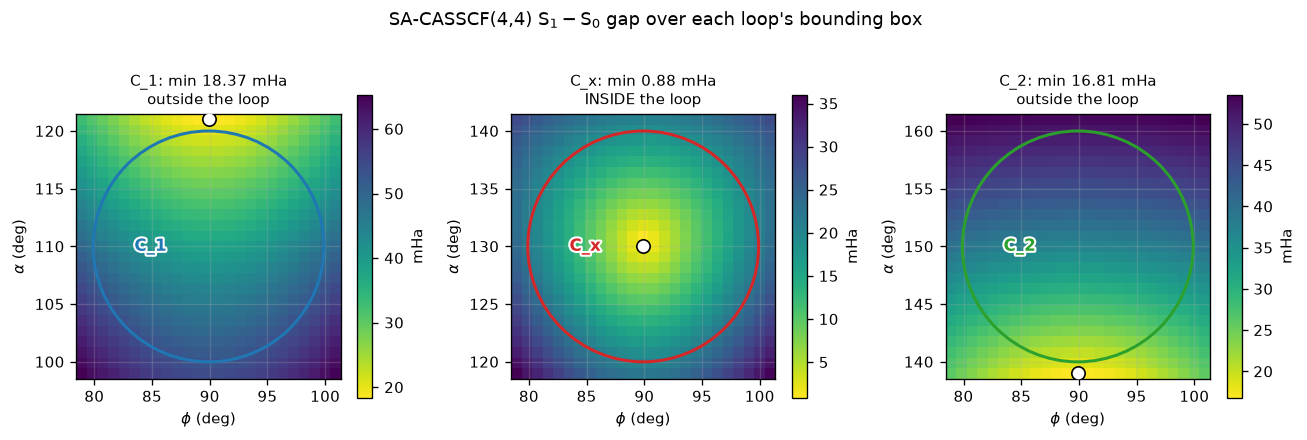

loop   CAS        min gap (Ha)       at (alpha, phi)  inside loop?
------------------------------------------------------------------
C_1    CAS(2,2)      0.064347  (  121.00,   78.90)  False
C_1    CAS(4,4)      0.018370  (  121.00,   89.90)  False
C_1    CAS(6,6)      0.019873  (  121.00,   89.90)  False
C_x    CAS(2,2)      0.020570  (  141.00,   89.90)  False
C_x    CAS(4,4)      0.000882  (  130.00,   89.90)  True
C_x    CAS(6,6)      0.000905  (  130.92,   89.90)  True
C_2    CAS(2,2)      0.000342  (  150.92,   89.90)  True
C_2    CAS(4,4)      0.016808  (  139.00,   89.90)  False
C_2    CAS(6,6)      0.015137  (  139.00,   89.90)  False


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
for ax, name in zip(axes, ["C_1", "C_x", "C_2"]):
    sc = load_scan(name, "4-4")
    if sc is None: continue
    A, P = np.meshgrid(sc.alphas, sc.phis, indexing="ij")
    pcm = ax.pcolormesh(P, A, sc.gap*1e3, shading="nearest", cmap="viridis_r")
    fig.colorbar(pcm, ax=ax, label="mHa")
    a_min, p_min, g_min = sc.min_gap_point()
    inside = BENCHMARK_LOOPS[name].encloses(a_min, p_min)
    ax.plot(p_min, a_min, "wo", ms=8, mec="k", zorder=7)
    draw_loops(ax, names=(name,), dx=-5.0)
    ax.set_title(f"{name}: min {g_min*1e3:.2f} mHa\n{'INSIDE' if inside else 'outside'} the loop",
                 fontsize=9)
    ax.set_xlabel(r"$\phi$ (deg)"); ax.set_ylabel(r"$\alpha$ (deg)"); ax.set_aspect("equal")
axes[0].set_ylabel(r"$\alpha$ (deg)")
fig.suptitle("SA-CASSCF(4,4) S$_1-$S$_0$ gap over each loop's bounding box", y=1.06)
plt.tight_layout(); plt.show()

print(f"{'loop':6s} {'CAS':9s} {'min gap (Ha)':>13s}  {'at (alpha, phi)':>20s}  inside loop?")
print("-"*66)
for name in ["C_1", "C_x", "C_2"]:
    for cas in ["2-2", "4-4", "6-6"]:
        sc = load_scan(name, cas)
        if sc is None: continue
        a, p, g = sc.min_gap_point()
        print(f"{name:6s} CAS({cas.replace('-',',')}) {g:13.6f}  ({a:8.2f},{p:8.2f})  "
              f"{BENCHMARK_LOOPS[name].encloses(a, p)}")

At CAS(4,4) the comparator agrees with the Berry phase on all three loops: a 0.9 mHa minimum
**inside** `C_x`, and for both controls a minimum pinned to the box edge nearest the seam with
a gap roughly twenty times larger &mdash; the signature of a slope, not a cone.

### Calibration against the exact answer

STO-3G is small enough that FCI is computable (1.66 M determinants, ~28 s/point), so the
truncated active spaces can be checked against the exact result in the same basis &mdash; the
same quantity the gap map of arXiv:2304.06070 Fig. 1a reports.

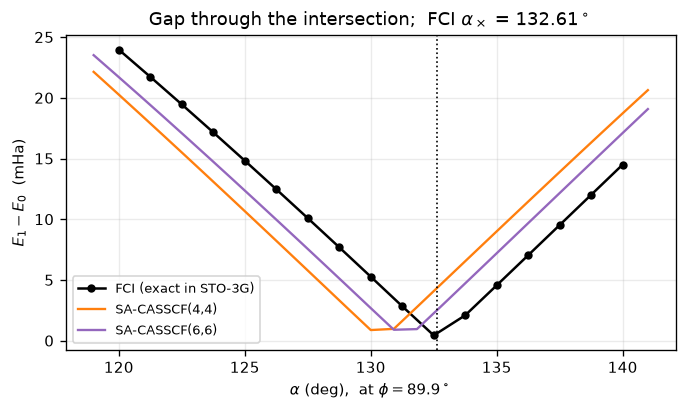

FCI minimum (parabolic):     alpha = 132.61 deg
SA-CASSCF(4,4) minimum:   alpha = 130.00 deg   (error vs FCI: -2.61 deg)
SA-CASSCF(6,6) minimum:   alpha = 130.92 deg   (error vs FCI: -1.70 deg)


In [9]:
fci_path = os.path.join(SCAN_DIR, "C_x_fci_17x1.npz")
if os.path.exists(fci_path):
    fr = ScanResult.load(fci_path)
    g = fr.gap[:, 0]
    fig, ax = plt.subplots(figsize=(5.8, 3.5))
    ax.plot(fr.alphas, g*1e3, "ko-", ms=4, label="FCI (exact in STO-3G)")
    for cas, col in [("4-4", "tab:orange"), ("6-6", "tab:purple")]:
        sc = load_scan("C_x", cas)
        if sc is None: continue
        j = int(np.argmin(np.abs(sc.phis - 89.9)))
        ax.plot(sc.alphas, sc.gap[:, j]*1e3, "-", color=col, lw=1.4,
                label=f"SA-CASSCF({cas.replace('-',',')})")
    i = int(np.nanargmin(g))
    y0, y1, y2 = g[i-1], g[i], g[i+1]; h = fr.alphas[1]-fr.alphas[0]
    a_star = fr.alphas[i] + 0.5*(y0-y2)/(y0-2*y1+y2)*h
    ax.axvline(a_star, color="k", ls=":", lw=1)
    ax.set_xlabel(r"$\alpha$ (deg),  at $\phi = 89.9^\circ$")
    ax.set_ylabel(r"$E_1 - E_0$  (mHa)")
    ax.set_title(rf"Gap through the intersection;  FCI $\alpha_\times$ = {a_star:.2f}$^\circ$")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

    print(f"FCI minimum (parabolic):     alpha = {a_star:.2f} deg")
    for cas in ["4-4", "6-6"]:
        sc = load_scan("C_x", cas)
        if sc is None: continue
        a, p, gg = sc.min_gap_point()
        print(f"SA-CASSCF({cas.replace('-',',')}) minimum:   alpha = {a:.2f} deg"
              f"   (error vs FCI: {a - a_star:+.2f} deg)")
else:
    print("No FCI reference found. Run: python examples/run_fci_reference.py --loop C_x --line")

The FCI gap is **linear in &alpha; on both sides of the minimum** &mdash; the signature of a cone
rather than an avoided crossing &mdash; and puts the intersection at
&alpha;<sub>&times;</sub> = 132.6&deg;, agreeing with the paper's &asymp;132&deg;. The truncated
active spaces sit about 2&deg; low and converge monotonically toward it.

That 2&deg; error is worth putting in perspective: it is irrelevant to a loop of radius 10&deg;
that encloses the intersection either way. **The topological question is far more forgiving
than the geometric one** &mdash; which is the practical argument for the Berry-phase approach.

## 7. Where the two methods disagree: CAS(2,2)

This is the interesting part, and it is a genuine disagreement rather than a numerical wobble.

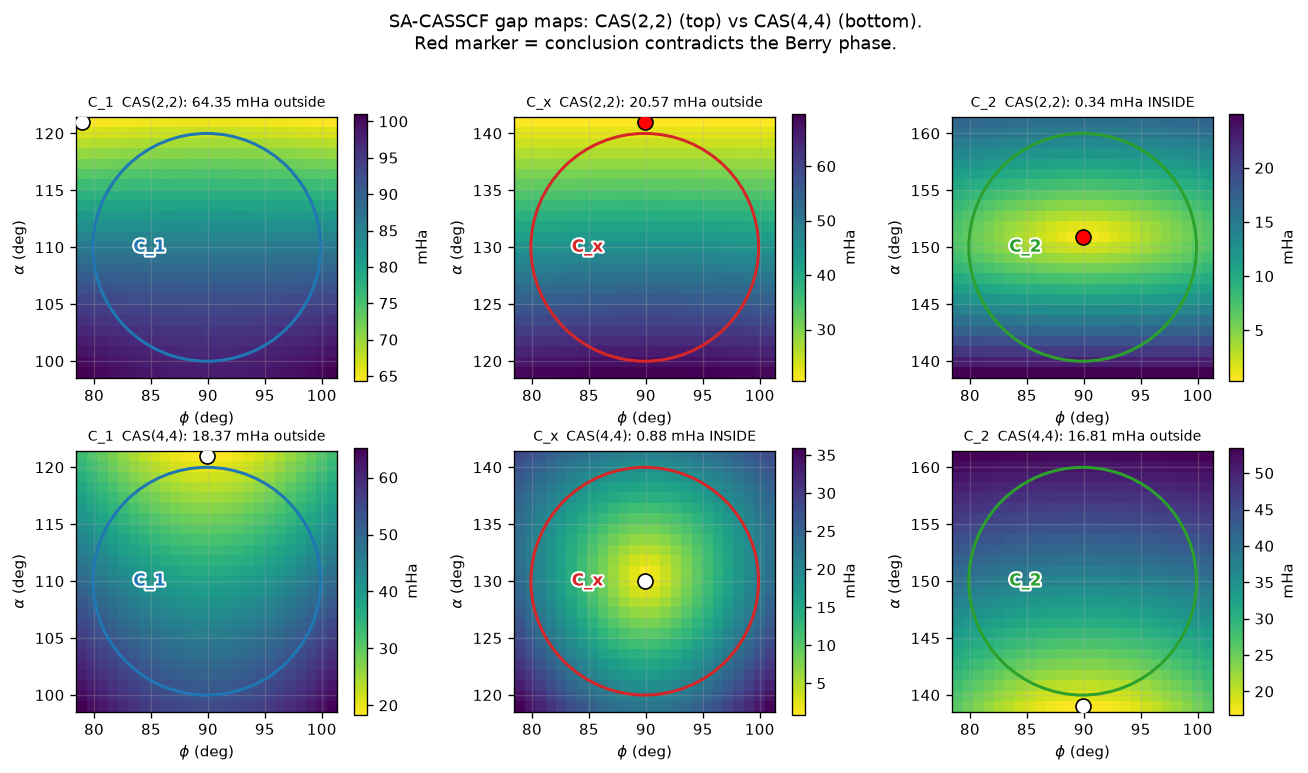

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6.2))
for col, name in enumerate(["C_1", "C_x", "C_2"]):
    for row, cas in enumerate(["2-2", "4-4"]):
        ax = axes[row, col]
        sc = load_scan(name, cas)
        if sc is None:
            ax.set_visible(False); continue
        A, P = np.meshgrid(sc.alphas, sc.phis, indexing="ij")
        pcm = ax.pcolormesh(P, A, sc.gap*1e3, shading="nearest", cmap="viridis_r")
        fig.colorbar(pcm, ax=ax, label="mHa")
        a, p, g = sc.min_gap_point()
        inside = BENCHMARK_LOOPS[name].encloses(a, p)
        ax.plot(p, a, "o", ms=9, mfc="red" if (inside != (name == "C_x")) else "white",
                mec="k", zorder=7)
        draw_loops(ax, names=(name,), dx=-5.0)
        ax.set_aspect("equal")
        ax.set_xlabel(r"$\phi$ (deg)"); ax.set_ylabel(r"$\alpha$ (deg)")
        ax.set_title(f"{name}  CAS({cas.replace('-',',')}): {g*1e3:.2f} mHa "
                     f"{'INSIDE' if inside else 'outside'}", fontsize=8.5)
fig.suptitle("SA-CASSCF gap maps: CAS(2,2) (top) vs CAS(4,4) (bottom).\n"
             "Red marker = conclusion contradicts the Berry phase.", y=1.02)
plt.tight_layout(); plt.show()

The CAS(2,2) row gets two of three loops **backwards**:

* inside the *trivial* loop `C_2` it finds a 0.34 mHa near-degeneracy &mdash; a spurious CI;
* inside the *true* CI loop `C_x` it finds nothing, its minimum sitting on the box edge.

The Berry phase, run at the very same CAS(2,2), gets all three right.

### Diagnosis

The spurious degeneracy is an artifact of the two-orbital active space, not a real feature.
Recomputing the gap at the spurious minimum with progressively larger active spaces:

In [11]:
diag_path = os.path.join(ROOT, "results", "diagnostics", "cas22_artifact.json")
diag = json.load(open(diag_path))
pt = diag["point"]
print(f"Gap at the spurious CAS(2,2) minimum, "
      f"(alpha, phi) = ({pt['alpha']:.2f}, {pt['phi']:.2f}):\n")
for row in diag["rows"]:
    note = "   <-- claims a conical intersection" if row["gap"] < 1e-3 else ""
    print(f"  {row['cas']:9s} gap = {row['gap']:.6f} Ha   converged={row['converged']}{note}")
print(f"\n{diag['verdict']}")
print("\n(reproduce with: python examples/diagnose_cas22_artifact.py)")

Gap at the spurious CAS(2,2) minimum, (alpha, phi) = (150.92, 89.90):

  CAS(2,2)  gap = 0.000345 Ha   converged=True   <-- claims a conical intersection
  CAS(4,4)  gap = 0.038347 Ha   converged=True
  CAS(6,6)  gap = 0.037863 Ha   converged=True
  CAS(8,8)  gap = 0.039675 Ha   converged=True

ARTIFACT: the larger active spaces agree there is no degeneracy here

(reproduce with: python examples/diagnose_cas22_artifact.py)


CAS(4,4), CAS(6,6) and CAS(8,8) all agree the gap there is ~0.04 Ha. The CAS(2,2) result is
converged nonsense.

**Why the two methods differ in their demands.** The Berry-phase workflow is *state-specific*:
it only ever tracks S0, and needs the active space to describe one state well enough to follow
it continuously. The comparator must place S1 correctly, and S1 at these geometries is an
excitation out of orbitals that a two-orbital active space does not contain. Averaging two
states over a CAS that cannot represent one of them produces a compromised orbital set and a
meaningless second root.

This is precisely the asymmetry the project brief anticipated, and it is acceptable provided
it is documented &mdash; which is the purpose of this section.

## 8. Conclusions

* **Both loops classes are correctly identified.** `C_x` gives a non-trivial Berry phase (&pi;),
  `C_1` and `C_2` give 0, at every active space and every discretization tested (36 runs).
* **The Berry phase is remarkably cheap and robust.** CAS(2,2) with N = 9 points &mdash; about
  one second of compute &mdash; already gives the right topological answer, and refining N or
  enlarging the CAS never changes the sign.
* **The comparator is the more demanding calculation.** It needs CAS(4,4) to be even
  qualitatively right. The smallest tested active space at which *both* methods give a stable
  and mutually consistent conclusion is therefore **CAS(4,4)**.
* **The CI location** from the comparator, (&alpha;, &phi;) &asymp; (130&ndash;131&deg;, 89.9&deg;)
  at CAS(4,4)/CAS(6,6), is consistent with the literature value &alpha; &asymp; 132&deg;,
  &phi; = 90&deg; obtained from FCI.

Limitations, and what the sign does and does not tell you, are in `docs/limitations.md`.